# catboost model: peer-relative outperformance, now with volume

predicts whether a fund will outperform / stay neutral vs / underperform its category peers
over the next 5 trading days. same label the rest of the project uses (tercile of excess
forward return vs category median), core features are the established 6-feature peer-relative
blueprint, and the feature set adds volume - built fresh from `market_data.parquet`, which the
earlier notebooks (01-06) never had. goal: a working catboost model with solid, leak-checked
results, and see whether volume actually earns its place next to the established features.

In [120]:
import pathlib
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW, PROC = ROOT / cfg['paths']['raw'], ROOT / cfg['paths']['processed']
H = cfg['labels']['horizon']            # forward-return horizon in trading days
MIN_GROUP = cfg['labels']['min_group']  # min peers a category needs that day to get a label

In [121]:
# Load Dataset 
d = pd.read_parquet(PROC / "dataset_catboost.parquet")

print(d.columns.tolist())
print(d.shape)
print(d.index)

features = [
    "beta_60d",
    "cat_n",
    "peer_rank_20d",
    "cs_rank_ret_5d",
    "ret_20d_skip5",
    "vol_20d",
    "cs_rank_dollar_vol",
    "vol_zscore",
]

['beta_60d', 'cat_n', 'peer_rank_20d', 'cs_rank_ret_5d', 'ret_20d_skip5', 'vol_20d', 'rel_volume_20d', 'cs_rank_dollar_vol', 'vol_zscore', 'label']
(3258519, 10)
MultiIndex([('2016-10-04', 'AADR'),
            ('2016-10-04', 'AAXJ'),
            ('2016-10-04', 'ACWF'),
            ('2016-10-04', 'ACWI'),
            ('2016-10-04', 'ACWX'),
            ('2016-10-04', 'ADRE'),
            ('2016-10-04',  'AEB'),
            ('2016-10-04',  'AFK'),
            ('2016-10-04', 'AFTY'),
            ('2016-10-04',  'AGG'),
            ...
            ('2026-07-02',  'XTL'),
            ('2026-07-02',  'XTN'),
            ('2026-07-02', 'XYLD'),
            ('2026-07-02', 'XYLG'),
            ('2026-07-02',  'YLD'),
            ('2026-07-02', 'YLDE'),
            ('2026-07-02',  'YXI'),
            ('2026-07-02',  'YYY'),
            ('2026-07-02',  'ZIG'),
            ('2026-07-02', 'ZROZ')],
           names=['date', 'ticker'], length=3258519)


In [183]:
# Build Labels
prices = pd.read_parquet(RAW / "prices.parquet")
metadata = pd.read_parquet(RAW / "metadata.parquet")

HORIZON = 20
SKIP = 5
THRESHOLD = 0.015
MIN_GROUP = 3

cat = metadata["category"].reindex(prices.columns)

counts = cat.value_counts()
keep_cats = counts[
    (counts >= MIN_GROUP) &
    (counts.index != "Uncategorized")
].index

cols = cat[cat.isin(keep_cats)].index
px = prices[cols]
cat = cat[cols]

print(f'funds kept for labeling: {len(cols)} | categories: {cat.nunique()}')

# 20-day forward return skipping the next 5 days
fwd = px.shift(-(HORIZON + SKIP)) / px.shift(-SKIP) - 1.0

# category peer average excluding the fund itself
grp_sum = fwd.T.groupby(cat).transform('sum').T
grp_n = fwd.notna().T.groupby(cat).transform('sum').T

peer_mean = (
    (grp_sum - fwd.fillna(0)) /
    (grp_n - fwd.notna().astype(int)).replace(0, np.nan)
)

rel = fwd - peer_mean

label = pd.DataFrame(
    np.where(
        rel > THRESHOLD,
        'Outperform',
        np.where(rel < -THRESHOLD, 'Underperform', 'Neutral')
    ),
    index=rel.index,
    columns=rel.columns
).where(rel.notna())


def stack(df):
    s = df.stack(future_stack=True)
    s.index.names = ['date', 'fund_id']
    return s


labels_long = pd.concat(
    {
        'fwd_ret': stack(fwd),
        'rel': stack(rel),
        'label': stack(label)
    },
    axis=1
).dropna(subset=['label']).reset_index()

label_map = {"Underperform": 0, "Neutral": 1, "Outperform": 2}
labels_long["target"] = labels_long["label"].map(label_map)

print('labels:', labels_long.shape)
print((labels_long['label'].value_counts(normalize=True) * 100).round(2))

funds kept for labeling: 1759 | categories: 36
labels: (3729760, 6)
label
Neutral         54.76
Underperform    23.07
Outperform      22.17
Name: proportion, dtype: float64


In [184]:
print(labels_long["label"].value_counts(normalize=True))

label
Neutral         0.547613
Underperform    0.230677
Outperform      0.221709
Name: proportion, dtype: float64


In [185]:
# Prepare figary baby 
# d's date level is stored as strings in the parquet, but labels_long's date
# column is a real Timestamp — a straight reindex silently matched 0 rows.
d.index = d.index.set_levels(pd.to_datetime(d.index.levels[0]), level="date")

lbl = (
    labels_long
    .rename(columns={"fund_id": "ticker"})
    .set_index(["date", "ticker"])
)

figary_df = d.copy()
figary_df["target"] = lbl["target"].reindex(figary_df.index)
figary_df["fwd_ret"] = lbl["fwd_ret"].reindex(figary_df.index)

figary_df = figary_df.dropna(subset=["target"])
figary_df["target"] = figary_df["target"].astype(int)
target = "target"

print(f"figary_df: {figary_df.shape}")
print(figary_df["target"].value_counts())

prices = pd.read_parquet(RAW / "prices.parquet")
last_obs = prices.apply(lambda col: col.last_valid_index())
data_end = prices.index.max()
dead_tickers = last_obs[last_obs < data_end - pd.offsets.BDay(10)].index

alive_mask = ~figary_df.index.get_level_values("ticker").isin(dead_tickers)
figary_alive = figary_df.loc[alive_mask]

print(f"full universe : {len(figary_df):,} rows")
print(f"survivors only: {len(figary_alive):,} rows")

figary_df: (3226983, 12)
target
1    1912409
0     667446
2     647128
Name: count, dtype: int64
full universe : 3,226,983 rows
survivors only: 2,918,196 rows


In [187]:
model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.045,
    depth=7,
    loss_function="MultiClass",
    eval_metric="TotalF1:average=Macro",
    l2_leaf_reg=5,
    random_strength=1,
    border_count=254,
    bootstrap_type="Bayesian",
    bagging_temperature=1,
class_weights={
    0: 1.5,
    1: 1.0,
    2: 1.5
},   task_type="GPU",
    random_seed=42,
    use_best_model=True,
    verbose=100,
    early_stopping_rounds=200,
)


# Chatgpt

In [154]:
# --- walk-forward evaluation + prediction storage ---

from copy import deepcopy
from sklearn.metrics import f1_score, accuracy_score

EMBARGO = HORIZON + SKIP  # trading days purged before each test year

date_index = figary_alive.index.get_level_values("date")
years = sorted(date_index.year.unique())

results = []
models = {}
predictions = []

for year in years:
    test_start = pd.Timestamp(f"{year}-01-01")
    test_end   = pd.Timestamp(f"{year}-12-31")
    cut = test_start - pd.offsets.BDay(EMBARGO)

    train_mask = date_index <= cut
    test_mask  = (date_index >= test_start) & (date_index <= test_end)

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        continue

    train  = figary_alive.loc[train_mask]
    test_data = figary_alive.loc[test_mask]

    X_test = test_data[features]
    y_test = test_data[target]

    # validation split inside training window
    train_dates = train.index.get_level_values("date")
    dates = np.sort(train_dates.unique())

    val_start = dates[int(len(dates) * 0.90)]
    val_cut   = val_start - pd.offsets.BDay(EMBARGO)

    fit_mask = train_dates <= val_cut
    val_mask = train_dates >= val_start

    X_fit, y_fit = train.loc[fit_mask, features], train.loc[fit_mask, target]
    X_val, y_val = train.loc[val_mask, features], train.loc[val_mask, target]

    if len(X_fit) == 0 or len(X_val) == 0:
        continue

    model.fit(
        X_fit,
        y_fit,
        eval_set=(X_val, y_val)
    )

    pred = model.predict(X_test).astype(int).ravel()

    macro_f1 = f1_score(y_test, pred, average="macro")
    acc = accuracy_score(y_test, pred)

    print(
        f"{year}: fit={len(X_fit):,} val={len(X_val):,} "
        f"test={len(X_test):,} | "
        f"Macro F1={macro_f1:.4f} | Acc={acc:.4f}"
    )

    # store predictions + returns
    out = test_data.copy()
    out["prediction"] = pred
    out["year"] = year

    predictions.append(out)

    results.append({
        "year": year,
        "fit": len(X_fit),
        "val": len(X_val),
        "test": len(X_test),
        "macro_f1": macro_f1,
        "accuracy": acc
    })

    # save independent model copy
    models[year] = deepcopy(model)


# results summary
results_df = pd.DataFrame(results)

print("\n=== walk-forward summary ===")
print(results_df)

print(f"\nmean Macro F1: {results_df['macro_f1'].mean():.4f}")
print(f"mean Accuracy: {results_df['accuracy'].mean():.4f}")


# combine predictions
predictions_df = pd.concat(predictions)

print("\nPrediction dataset:")
print(predictions_df.shape)


# --- portfolio evaluation ---

print("\n=== predicted outperform performance ===")

winners = predictions_df[predictions_df["prediction"] == 2]

print("Number of picks:", len(winners))
print("Average forward return:", winners["fwd_ret"].mean())
print("Median forward return:", winners["fwd_ret"].median())


print("\n=== universe performance ===")

print("Average forward return:",
      predictions_df["fwd_ret"].mean())


# long-short spread
longs = predictions_df[predictions_df["prediction"] == 2]["fwd_ret"]
shorts = predictions_df[predictions_df["prediction"] == 0]["fwd_ret"]

print("\n=== Long-short spread ===")
print("Outperform avg - Underperform avg:",
      longs.mean() - shorts.mean())

0:	learn: 0.4389502	test: 0.2988046	best: 0.2988046 (0)	total: 9.74ms	remaining: 48.7s
100:	learn: 0.5729877	test: 0.2792596	best: 0.2994457 (8)	total: 990ms	remaining: 48s
200:	learn: 0.6309005	test: 0.2698803	best: 0.2994457 (8)	total: 2.09s	remaining: 50s
bestTest = 0.2994456975
bestIteration = 8
Shrink model to first 9 iterations.
2017: fit=9,706 val=3,544 test=234,288 | Macro F1=0.2655 | Acc=0.3172
0:	learn: 0.4492541	test: 0.4102402	best: 0.4102402 (0)	total: 15.7ms	remaining: 1m 18s
100:	learn: 0.5100272	test: 0.4450525	best: 0.4489453 (50)	total: 1.3s	remaining: 1m 3s
200:	learn: 0.5285568	test: 0.4431924	best: 0.4489453 (50)	total: 2.62s	remaining: 1m 2s
bestTest = 0.4489452967
bestIteration = 50
Shrink model to first 51 iterations.
2018: fit=216,805 val=27,696 test=259,437 | Macro F1=0.4084 | Acc=0.4136
0:	learn: 0.3819480	test: 0.3187861	best: 0.3187861 (0)	total: 16.1ms	remaining: 1m 20s
100:	learn: 0.4790432	test: 0.3894166	best: 0.3917230 (44)	total: 1.39s	remaining: 1m 7

In [155]:
# --- rolling training window experiment: walk-forward evaluation ---

from copy import deepcopy
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

EMBARGO = HORIZON + SKIP

WINDOWS = {
    "All": None,
    "5Y": 5,
    "3Y": 3,
    "2Y": 2,
}

date_index = figary_alive.index.get_level_values("date")
years = sorted(date_index.year.unique())

all_results = []
all_predictions = {}
all_confusions = {}
all_models = {}

for window_name, window_years in WINDOWS.items():

    print("\n" + "=" * 80)
    print(f"TRAINING WINDOW: {window_name}")
    print("=" * 80)

    results = []
    predictions = []
    models = {}

    aggregate_cm = np.zeros((3, 3), dtype=int)

    for year in years:

        test_start = pd.Timestamp(f"{year}-01-01")
        test_end = pd.Timestamp(f"{year}-12-31")

        # embargo cutoff before test year
        cut = test_start - pd.offsets.BDay(EMBARGO)

        # -------------------------------
        # training window selection
        # -------------------------------

        if window_years is None:
            train_mask = date_index <= cut

        else:
            train_start = pd.Timestamp(
                f"{year - window_years}-01-01"
            )

            train_mask = (
                (date_index >= train_start)
                &
                (date_index <= cut)
            )

        test_mask = (
            (date_index >= test_start)
            &
            (date_index <= test_end)
        )

        if train_mask.sum() == 0 or test_mask.sum() == 0:
            continue


        train = figary_alive.loc[train_mask]
        test_data = figary_alive.loc[test_mask]

        X_test = test_data[features]
        y_test = test_data[target]


        # -------------------------------
        # validation split (same logic)
        # -------------------------------

        train_dates = train.index.get_level_values("date")
        dates = np.sort(train_dates.unique())

        val_start = dates[int(len(dates) * 0.90)]
        val_cut = val_start - pd.offsets.BDay(EMBARGO)

        fit_mask = train_dates <= val_cut
        val_mask = train_dates >= val_start

        X_fit = train.loc[fit_mask, features]
        y_fit = train.loc[fit_mask, target]

        X_val = train.loc[val_mask, features]
        y_val = train.loc[val_mask, target]


        if len(X_fit) == 0 or len(X_val) == 0:
            continue


        # -------------------------------
        # fresh model for every run
        # -------------------------------

        model_run = deepcopy(model)

        model_run.fit(
            X_fit,
            y_fit,
            eval_set=(X_val, y_val)
        )


        pred = model_run.predict(X_test).astype(int).ravel()


        # metrics
        macro_f1 = f1_score(
            y_test,
            pred,
            average="macro"
        )

        acc = accuracy_score(
            y_test,
            pred
        )

        cm = confusion_matrix(
            y_test,
            pred,
            labels=[0,1,2]
        )

        aggregate_cm += cm


        print(
            f"{window_name} | {year}: "
            f"fit={len(X_fit):,} "
            f"val={len(X_val):,} "
            f"test={len(X_test):,} "
            f"| F1={macro_f1:.4f} "
            f"| Acc={acc:.4f}"
        )


        # store predictions
        out = test_data.copy()

        out["prediction"] = pred
        out["year"] = year
        out["window"] = window_name

        predictions.append(out)


        results.append({
            "window": window_name,
            "year": year,
            "fit": len(X_fit),
            "val": len(X_val),
            "test": len(X_test),
            "macro_f1": macro_f1,
            "accuracy": acc
        })


        models[year] = model_run


    # store experiment outputs

    results_df_window = pd.DataFrame(results)

    all_results.append(results_df_window)

    all_predictions[window_name] = pd.concat(predictions)

    all_confusions[window_name] = aggregate_cm

    all_models[window_name] = models
# --- experiment summary + portfolio evaluation ---

summary_rows = []

for window_name in WINDOWS.keys():

    print("\n" + "=" * 80)
    print(f"RESULTS: {window_name}")
    print("=" * 80)

    # yearly metrics
    window_results = (
        pd.concat(all_results)
        .query("window == @window_name")
        .copy()
    )

    print("\n=== yearly metrics ===")
    print(window_results)

    print(
        f"\nMean Macro F1: "
        f"{window_results['macro_f1'].mean():.4f}"
    )

    print(
        f"Mean Accuracy: "
        f"{window_results['accuracy'].mean():.4f}"
    )


    # -------------------------------
    # confusion matrix
    # -------------------------------

    print("\n=== aggregate confusion matrix ===")

    cm = all_confusions[window_name]

    cm_df = pd.DataFrame(
        cm,
        index=["True_0", "True_1", "True_2"],
        columns=["Pred_0", "Pred_1", "Pred_2"]
    )

    print(cm_df)


    print("\n=== classification report ===")

    preds = all_predictions[window_name]

    print(
        classification_report(
            preds[target],
            preds["prediction"],
            labels=[0,1,2]
        )
    )


    # -------------------------------
    # portfolio metrics
    # -------------------------------

    print("\n=== portfolio evaluation ===")

    winners = preds[
        preds["prediction"] == 2
    ]

    losers = preds[
        preds["prediction"] == 0
    ]


    winner_return = winners["fwd_ret"].mean()
    loser_return = losers["fwd_ret"].mean()
    universe_return = preds["fwd_ret"].mean()

    spread = winner_return - loser_return

    print(
        "Predicted Outperform picks:",
        len(winners)
    )

    print(
        "Predicted Outperform avg return:",
        winner_return
    )

    print(
        "Predicted Underperform avg return:",
        loser_return
    )

    print(
        "Universe avg return:",
        universe_return
    )

    print(
        "Long-short spread:",
        spread
    )


    summary_rows.append({

        "window": window_name,

        "mean_macro_f1":
            window_results["macro_f1"].mean(),

        "mean_accuracy":
            window_results["accuracy"].mean(),

        "n_outperform_picks":
            len(winners),

        "outperform_avg_return":
            winner_return,

        "underperform_avg_return":
            loser_return,

        "universe_avg_return":
            universe_return,

        "long_short_spread":
            spread
    })


# -------------------------------
# final comparison table
# -------------------------------

experiment_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(
        "mean_macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("FINAL WINDOW COMPARISON")
print("=" * 80)

display(experiment_summary)


# Keep best experiment objects easy to access

print("\nAvailable prediction sets:")
print(list(all_predictions.keys()))

print("\nAvailable confusion matrices:")
print(list(all_confusions.keys()))


TRAINING WINDOW: All
0:	learn: 0.4389502	test: 0.2988046	best: 0.2988046 (0)	total: 10.7ms	remaining: 53.5s
100:	learn: 0.5729877	test: 0.2792596	best: 0.2994457 (8)	total: 1.1s	remaining: 53.4s
200:	learn: 0.6309005	test: 0.2698803	best: 0.2994457 (8)	total: 2.22s	remaining: 53s
bestTest = 0.2994456975
bestIteration = 8
Shrink model to first 9 iterations.
All | 2017: fit=9,706 val=3,544 test=234,288 | F1=0.2655 | Acc=0.3172
0:	learn: 0.4492541	test: 0.4102402	best: 0.4102402 (0)	total: 16.1ms	remaining: 1m 20s
100:	learn: 0.5100272	test: 0.4450525	best: 0.4489453 (50)	total: 1.34s	remaining: 1m 5s
200:	learn: 0.5285568	test: 0.4431924	best: 0.4489453 (50)	total: 3s	remaining: 1m 11s
bestTest = 0.4489452967
bestIteration = 50
Shrink model to first 51 iterations.
All | 2018: fit=216,805 val=27,696 test=259,437 | F1=0.4084 | Acc=0.4136
0:	learn: 0.3819480	test: 0.3187861	best: 0.3187861 (0)	total: 14.2ms	remaining: 1m 10s
100:	learn: 0.4790432	test: 0.3894166	best: 0.3917230 (44)	total:

,window,mean_macro_f1,mean_accuracy,n_outperform_picks,outperform_avg_return,underperform_avg_return,universe_avg_return,long_short_spread
0,3Y,0.403916,0.417723,1476756,0.009265,0.008007,0.007891,0.001258
1,5Y,0.398916,0.413322,1556103,0.009296,0.007843,0.007891,0.001453
2,All,0.397804,0.414027,1616140,0.009247,0.007767,0.007891,0.001480
3,2Y,0.397418,0.413121,1467724,0.009033,0.008343,0.007891,0.000690



Available prediction sets:
['All', '5Y', '3Y', '2Y']

Available confusion matrices:
['All', '5Y', '3Y', '2Y']


# Normal

In [188]:
# --- rolling training window experiment: fixed test year, varying window length ---

from copy import deepcopy
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

EMBARGO = HORIZON + SKIP

# window lengths expressed in months for uniform handling
WINDOWS = {
    "6M": 6,
    "1Y": 12,
    "2Y": 24,
    "3Y": 36,
    "4Y": 48,
    "5Y": 60,
}

TEST_YEAR = 2026

date_index = figary_alive.index.get_level_values("date")

test_start = pd.Timestamp(f"{TEST_YEAR}-01-01")
test_end = pd.Timestamp(f"{TEST_YEAR}-12-31")

cut = test_start - pd.offsets.BDay(EMBARGO)

test_mask = (
    (date_index >= test_start)
    &
    (date_index <= test_end)
)

test_data = figary_alive.loc[test_mask]
X_test = test_data[features]
y_test = test_data[target]

all_results = []
all_predictions = {}
all_confusions = {}
all_models = {}

for window_name, window_months in WINDOWS.items():

    print("\n" + "=" * 80)
    print(f"TRAINING WINDOW: {window_name}")
    print("=" * 80)

    train_start = test_start - pd.DateOffset(months=window_months)

    train_mask = (
        (date_index >= train_start)
        &
        (date_index <= cut)
    )

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        print(f"Skipping {window_name}: no data in range")
        continue

    train = figary_alive.loc[train_mask]

    # -------------------------------
    # validation split (same logic)
    # -------------------------------

    train_dates = train.index.get_level_values("date")
    dates = np.sort(train_dates.unique())

    val_start = dates[int(len(dates) * 0.90)]
    val_cut = val_start - pd.offsets.BDay(EMBARGO)

    fit_mask = train_dates <= val_cut
    val_mask = train_dates >= val_start

    X_fit = train.loc[fit_mask, features]
    y_fit = train.loc[fit_mask, target]

    X_val = train.loc[val_mask, features]
    y_val = train.loc[val_mask, target]

    if len(X_fit) == 0 or len(X_val) == 0:
        print(f"Skipping {window_name}: empty fit/val split")
        continue

    # -------------------------------
    # fresh model for every run
    # -------------------------------

    model_run = deepcopy(model)
    # -------------------------------
    # recency sample weights
    # -------------------------------

    fit_dates = train.loc[fit_mask].index.get_level_values("date")

    fit_dates = train.loc[fit_mask].index.get_level_values("date")

    max_train_date = fit_dates.max()

    age_years = (
        (max_train_date - fit_dates).days / 365.25
    ).to_numpy()
    
    decay_rate = 0.5
    
    sample_weight = np.exp(-decay_rate * age_years)
    
    # normalize
    sample_weight = sample_weight / sample_weight.mean()
    
    print(
        f"weights: min={sample_weight.min():.3f}, "
        f"max={sample_weight.max():.3f}, "
        f"mean={sample_weight.mean():.3f}")
    model_run.fit(
    X_fit,
    y_fit,
    sample_weight=sample_weight,
    eval_set=(X_val, y_val)
)

    pred = model_run.predict(X_test).astype(int).ravel()

    # metrics
    macro_f1 = f1_score(y_test, pred, average="macro")
    acc = accuracy_score(y_test, pred)
    cm = confusion_matrix(y_test, pred, labels=[0, 1, 2])

    print(
        f"{window_name}: "
        f"fit={len(X_fit):,} "
        f"val={len(X_val):,} "
        f"test={len(X_test):,} "
        f"| F1={macro_f1:.4f} "
        f"| Acc={acc:.4f}"
    )

    # store predictions
    out = test_data.copy()
    out["prediction"] = pred
    out["window"] = window_name
    all_predictions[window_name] = out

    all_confusions[window_name] = cm
    all_models[window_name] = model_run

    all_results.append({
        "window": window_name,
        "train_start": train_start,
        "fit": len(X_fit),
        "val": len(X_val),
        "test": len(X_test),
        "macro_f1": macro_f1,
        "accuracy": acc
    })


results_df = pd.DataFrame(all_results)
print("\n" + "=" * 80)
print(f"WINDOW COMPARISON — TEST YEAR {TEST_YEAR}")
print("=" * 80)
print(results_df)


TRAINING WINDOW: 6M
weights: min=0.933, max=1.069, mean=1.000
0:	learn: 0.4806314	test: 0.5003441	best: 0.5003441 (0)	total: 36.9ms	remaining: 3m 4s
100:	learn: 0.5515716	test: 0.5230517	best: 0.5262405 (59)	total: 2.18s	remaining: 1m 45s
200:	learn: 0.5849812	test: 0.5223370	best: 0.5262405 (59)	total: 3.77s	remaining: 1m 29s
bestTest = 0.5262404572
bestIteration = 59
Shrink model to first 60 iterations.
6M: fit=92,262 val=13,728 test=137,592 | F1=0.4775 | Acc=0.5470

TRAINING WINDOW: 1Y
weights: min=0.830, max=1.190, mean=1.000
0:	learn: 0.4870030	test: 0.4922400	best: 0.4922400 (0)	total: 17.4ms	remaining: 1m 27s
100:	learn: 0.5375525	test: 0.5000932	best: 0.5045285 (1)	total: 1.58s	remaining: 1m 16s
200:	learn: 0.5639258	test: 0.5046386	best: 0.5052967 (188)	total: 3.1s	remaining: 1m 13s
300:	learn: 0.5813263	test: 0.5052383	best: 0.5063287 (241)	total: 4.66s	remaining: 1m 12s
400:	learn: 0.5942165	test: 0.5036231	best: 0.5063287 (241)	total: 6.12s	remaining: 1m 10s
bestTest = 0.5

In [189]:
# --- portfolio evaluation per window ---

summary_rows = []

for window_name in WINDOWS.keys():

    if window_name not in all_predictions:
        continue

    print("\n" + "=" * 80)
    print(f"RESULTS: {window_name}")
    print("=" * 80)

    preds = all_predictions[window_name]

    print("\n=== confusion matrix ===")
    cm_df = pd.DataFrame(
        all_confusions[window_name],
        index=["True_0", "True_1", "True_2"],
        columns=["Pred_0", "Pred_1", "Pred_2"]
    )
    print(cm_df)

    print("\n=== classification report ===")
    print(classification_report(preds[target], preds["prediction"], labels=[0, 1, 2]))

    # portfolio metrics
    winners = preds[preds["prediction"] == 2]
    losers = preds[preds["prediction"] == 0]

    winner_return = winners["fwd_ret"].mean()
    loser_return = losers["fwd_ret"].mean()
    universe_return = preds["fwd_ret"].mean()
    spread = winner_return - loser_return

    print("\n=== portfolio evaluation ===")
    print("Predicted Outperform picks:", len(winners))
    print("Predicted Outperform avg return:", winner_return)
    print("Predicted Underperform avg return:", loser_return)
    print("Universe avg return:", universe_return)
    print("Long-short spread:", spread)

    row = results_df.query("window == @window_name").iloc[0]

    summary_rows.append({
        "window": window_name,
        "train_start": row["train_start"],
        "fit": row["fit"],
        "macro_f1": row["macro_f1"],
        "accuracy": row["accuracy"],
        "n_outperform_picks": len(winners),
        "outperform_avg_return": winner_return,
        "underperform_avg_return": loser_return,
        "universe_avg_return": universe_return,
        "long_short_spread": spread
    })


experiment_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("long_short_spread", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print(f"FINAL WINDOW COMPARISON — TEST YEAR {TEST_YEAR}")
print("=" * 80)
display(experiment_summary)


RESULTS: 6M

=== confusion matrix ===
        Pred_0  Pred_1  Pred_2
True_0   11281   12002   10556
True_1    9268   52104   11421
True_2    7664   11424   11872

=== classification report ===
              precision    recall  f1-score   support

           0       0.40      0.33      0.36     33839
           1       0.69      0.72      0.70     72793
           2       0.35      0.38      0.37     30960

    accuracy                           0.55    137592
   macro avg       0.48      0.48      0.48    137592
weighted avg       0.54      0.55      0.54    137592


=== portfolio evaluation ===
Predicted Outperform picks: 33849
Predicted Outperform avg return: 0.02323558532156351
Predicted Underperform avg return: 0.009977518432585023
Universe avg return: 0.011674123605599628
Long-short spread: 0.013258066888978489

RESULTS: 1Y

=== confusion matrix ===
        Pred_0  Pred_1  Pred_2
True_0   10397   15741    7701
True_1    6814   58980    6999
True_2    6680   14945    9335

=== cl

,window,train_start,fit,macro_f1,accuracy,n_outperform_picks,outperform_avg_return,underperform_avg_return,universe_avg_return,long_short_spread
0,6M,2025-07-01,92262,0.477514,0.546958,33849,0.023236,0.009978,0.011674,0.013258
1,1Y,2025-01-01,237348,0.475257,0.572068,24035,0.016835,0.009150,0.011674,0.007685
2,4Y,2022-01-01,1133405,0.447066,0.558753,19126,0.016493,0.009220,0.011674,0.007273
3,3Y,2023-01-01,833298,0.454213,0.561973,19937,0.015766,0.009894,0.011674,0.005872
4,2Y,2024-01-01,538186,0.453622,0.559480,20833,0.013391,0.012106,0.011674,0.001284
5,5Y,2021-01-01,1424770,0.450086,0.532625,26483,0.011335,0.012660,0.011674,-0.001324


In [190]:
print(model._canonized_params)

None


In [191]:
pred_class2 = pred == 2

print("Number of picks:", pred_class2.sum())
print("Average return:", labels_test.loc[pred_class2, "fwd_ret"].mean())
print("Median return:", labels_test.loc[pred_class2, "fwd_ret"].median())

Number of picks: 26483


NameError: name 'labels_test' is not defined

In [133]:
confidence = np.max(proba, axis=1)

confidence.mean()

0.4598930931481712

In [137]:
max_prob = proba.max(axis=1)

pred = np.where(
    max_prob < 0.55,
    1,   # neutral
    proba.argmax(axis=1)
)
pred_threshold = np.where(
    max_prob < 0.55,
    1,
    proba.argmax(axis=1)
)

In [151]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[21192  1241 30139]
 [ 9275 10704 14345]
 [18702  1228 30766]]
              precision    recall  f1-score   support

           0       0.43      0.40      0.42     52572
           1       0.81      0.31      0.45     34324
           2       0.41      0.61      0.49     50696

    accuracy                           0.46    137592
   macro avg       0.55      0.44      0.45    137592
weighted avg       0.52      0.46      0.45    137592



In [140]:
from sklearn.metrics import confusion_matrix, classification_report

for t in [0.45, 0.47, 0.50, 0.52]:
    pred_t = np.where(
        proba.max(axis=1) < t,
        1,
        proba.argmax(axis=1)
    )

    print("="*40)
    print("Threshold:", t)
    print(confusion_matrix(y_test, pred_t))
    print(classification_report(y_test, pred_t))

Threshold: 0.45
[[11852 34314  6406]
 [ 2277 30359  1688]
 [ 9542 33616  7538]]
              precision    recall  f1-score   support

           0       0.50      0.23      0.31     52572
           1       0.31      0.88      0.46     34324
           2       0.48      0.15      0.23     50696

    accuracy                           0.36    137592
   macro avg       0.43      0.42      0.33    137592
weighted avg       0.45      0.36      0.32    137592

Threshold: 0.47
[[ 7534 42290  2748]
 [ 1164 32632   528]
 [ 5823 41387  3486]]
              precision    recall  f1-score   support

           0       0.52      0.14      0.22     52572
           1       0.28      0.95      0.43     34324
           2       0.52      0.07      0.12     50696

    accuracy                           0.32    137592
   macro avg       0.44      0.39      0.26    137592
weighted avg       0.46      0.32      0.24    137592

Threshold: 0.5
[[ 3053 49111   408]
 [  335 33937    52]
 [ 1906 48416   374]]

In [143]:
p0 = proba[:,0]
p2 = proba[:,2]

margin = p2 - p0

pred_margin = np.where(
    abs(margin) < 0.05,
    1,
    np.where(margin > 0, 2, 0)
)
print(confusion_matrix(y_test, pred_margin))
print(classification_report(y_test, pred_margin))

[[ 9929 30571 12072]
 [ 5028 22329  6967]
 [ 8662 28135 13899]]
              precision    recall  f1-score   support

           0       0.42      0.19      0.26     52572
           1       0.28      0.65      0.39     34324
           2       0.42      0.27      0.33     50696

    accuracy                           0.34    137592
   macro avg       0.37      0.37      0.33    137592
weighted avg       0.38      0.34      0.32    137592



In [144]:
predicted_winners = pred_margin == 2

future_returns[predicted_winners].mean()

NameError: name 'future_returns' is not defined

# Train catboost with optimized parameters

In [43]:
d = pd.read_parquet(PROC / "dataset_catboost.parquet")

print(d.columns.tolist())
print(d.shape)
print(d.index)

['beta_60d', 'cat_n', 'peer_rank_20d', 'cs_rank_ret_5d', 'ret_20d_skip5', 'vol_20d', 'rel_volume_20d', 'cs_rank_dollar_vol', 'vol_zscore', 'label']
(3258519, 10)
MultiIndex([('2016-10-04', 'AADR'),
            ('2016-10-04', 'AAXJ'),
            ('2016-10-04', 'ACWF'),
            ('2016-10-04', 'ACWI'),
            ('2016-10-04', 'ACWX'),
            ('2016-10-04', 'ADRE'),
            ('2016-10-04',  'AEB'),
            ('2016-10-04',  'AFK'),
            ('2016-10-04', 'AFTY'),
            ('2016-10-04',  'AGG'),
            ...
            ('2026-07-02',  'XTL'),
            ('2026-07-02',  'XTN'),
            ('2026-07-02', 'XYLD'),
            ('2026-07-02', 'XYLG'),
            ('2026-07-02',  'YLD'),
            ('2026-07-02', 'YLDE'),
            ('2026-07-02',  'YXI'),
            ('2026-07-02',  'YYY'),
            ('2026-07-02',  'ZIG'),
            ('2026-07-02', 'ZROZ')],
           names=['date', 'ticker'], length=3258519)


In [197]:
# define features and target
features = [
    "beta_60d",
    "cat_n",
    "peer_rank_20d",
    "cs_rank_ret_5d",
    "ret_20d_skip5",
    "vol_20d",
    "cs_rank_dollar_vol",
    "vol_zscore",
]
target = "label"
def purge_cutoff(trading_index, test_start, h):
    pos = trading_index.searchsorted(pd.Timestamp(test_start))
    return trading_index[max(pos - h, 0)]
proba_2026[:, 2]

array([0.11824864, 0.15418466, 0.20984846, ..., 0.32627522, 0.3310872 ,
       0.21567139])

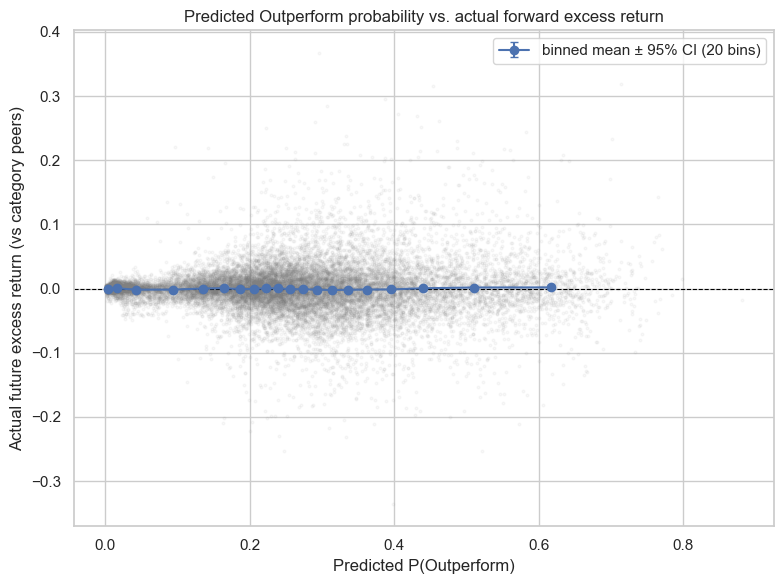

Spearman correlation: -0.0138


In [196]:
figary_df["rel"] = lbl["rel"].reindex(figary_df.index)
import matplotlib.pyplot as plt
import numpy as np

plot_df = pd.DataFrame({
    "score": proba_2026[:, 2],  # P(Outperform)
    "excess_ret": figary_df.loc[X_2026.index, "rel"],
}).dropna()

N_BINS = 20
plot_df["bin"] = pd.qcut(plot_df["score"], N_BINS, duplicates="drop")

binned = (
    plot_df.groupby("bin", observed=True)
    .agg(
        score_mid=("score", "mean"),
        excess_mean=("excess_ret", "mean"),
        excess_se=("excess_ret", lambda s: s.std() / np.sqrt(len(s))),
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 6))

# raw cloud, subsampled + faint, just for texture
sample = plot_df.sample(min(20000, len(plot_df)), random_state=42)
ax.scatter(sample["score"], sample["excess_ret"], s=4, alpha=0.05, color="gray")

# binned trend with 95% CI
ax.errorbar(
    binned["score_mid"], binned["excess_mean"],
    yerr=1.96 * binned["excess_se"],
    fmt="o-", color="C0", capsize=3,
    label=f"binned mean ± 95% CI ({N_BINS} bins)"
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Predicted P(Outperform)")
ax.set_ylabel("Actual future excess return (vs category peers)")
ax.set_title("Predicted Outperform probability vs. actual forward excess return")
ax.legend()
plt.tight_layout()
plt.show()

corr = plot_df["score"].corr(plot_df["excess_ret"], method="spearman")
print(f"Spearman correlation: {corr:.4f}")

In [195]:
test_start = pd.Timestamp("2026-01-01")
test_end   = pd.Timestamp("2026-12-31")

date_index = figary_alive.index.get_level_values("date")
test_mask = (date_index >= test_start) & (date_index <= test_end)

X_2026 = figary_alive.loc[test_mask, features]
proba_2026 = model_run.predict_proba(X_2026)
proba_2026

array([[0.14835678, 0.73339459, 0.11824864],
       [0.34141115, 0.50440418, 0.15418466],
       [0.47582575, 0.31432579, 0.20984846],
       ...,
       [0.14462781, 0.52909698, 0.32627522],
       [0.31181192, 0.35710088, 0.3310872 ],
       [0.61844862, 0.16587999, 0.21567139]])

In [101]:
prices = pd.read_parquet(RAW / "prices.parquet")

last_obs = prices.apply(lambda col: col.last_valid_index())
data_end = prices.index.max()

# tickers whose price series ends more than ~10 trading days before the data ends
dead = last_obs[last_obs < data_end - pd.offsets.BDay(10)]

print(f"total tickers : {prices.shape[1]}")
print(f"dead tickers  : {len(dead)} ({len(dead)/prices.shape[1]:.1%})")
print(dead.sort_values())   # most recent deaths, if any

total tickers : 1975
dead tickers  : 345 (17.5%)
ticker
NOMO    2018-01-24
OTR     2018-01-24
OFSSZ   2021-03-11
MOM     2021-03-29
USHG    2021-03-29
           ...    
HLGE    2025-06-30
FLHK    2025-07-07
FBZ     2025-07-21
CLDL    2025-07-30
HART    2025-08-19
Length: 345, dtype: datetime64[ns]


In [102]:
dead_tickers = dead.index

alive_mask = ~figary_df.index.get_level_values("ticker").isin(dead_tickers)
figary_alive = figary_df.loc[alive_mask]

print(f"full universe : {len(figary_df):,} rows")
print(f"survivors only: {len(figary_alive):,} rows")


full universe : 3,226,983 rows
survivors only: 2,918,196 rows


In [16]:

for year in DEV_YEARS:

    test_start = pd.Timestamp(f"{year}-01-01")
    test_end = pd.Timestamp(f"{year}-12-31")

    cut = test_start - pd.offsets.BDay(H)

    train_mask = date_index <= cut
    test_mask = (date_index >= test_start) & (date_index <= test_end)

    X_train = d.loc[train_mask, features]
    y_train = d.loc[train_mask, target]

    X_test = d.loc[test_mask, features]
    y_test = d.loc[test_mask, target]

    print(
        f"{year}: "
        f"train={len(X_train):,} "
        f"test={len(X_test):,}"
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_test, y_test),
    )

    pred = model.predict(X_test).astype(int).ravel()

    print(
        f"Macro F1: {f1_score(y_test, pred, average='macro'):.4f}"
    )

KeyError: 'target'

In [22]:
# HUGE MACRO F1 0.4248
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

model.save_model(MODEL_DIR / "catboost_walkforward_2026_omg.cbm")
import json

with open(MODEL_DIR / "features.json", "w") as f:
    json.dump(features, f, indent=2)
with open(MODEL_DIR / "params.json", "w") as f:
    json.dump(model.get_params(), f, indent=2, default=str)

In [18]:
from catboost import CatBoostClassifier
import pandas as pd

H = 5  # label horizon / embargo

test_start = pd.Timestamp("2026-01-01")
test_end   = pd.Timestamp("2026-12-31")

cut = test_start - pd.offsets.BDay(5)
date_index = d.index.get_level_values("date")

train_mask = date_index <= cut
test_mask = (date_index >= test_start) & (date_index <= test_end)

X_train = d.loc[train_mask, features]
y_train = d.loc[train_mask, target]

X_test = d.loc[test_mask, features]
y_test = d.loc[test_mask, target]

print(f"Train rows: {len(X_train):,}")
print(f"Test rows : {len(X_test):,}")

model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.045,
    depth=7,
    loss_function="MultiClass",
    eval_metric="TotalF1:average=Macro",
    l2_leaf_reg=5,
    random_strength=1,
    border_count=254,
    bootstrap_type="Bayesian",
    bagging_temperature=1,
    class_weights={0: 1.25, 1: 1.0, 2: 1.25},
    task_type="GPU",
    random_seed=42,
    use_best_model=True,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
)

Train rows: 3,089,535
Test rows : 163,992
0:	learn: 0.4026443	test: 0.4051533	best: 0.4051533 (0)	total: 143ms	remaining: 11m 53s
100:	learn: 0.4204478	test: 0.4201048	best: 0.4204956 (98)	total: 4.29s	remaining: 3m 28s
200:	learn: 0.4273857	test: 0.4216571	best: 0.4226303 (142)	total: 8.49s	remaining: 3m 22s
300:	learn: 0.4317259	test: 0.4224542	best: 0.4226303 (142)	total: 12.7s	remaining: 3m 17s
400:	learn: 0.4351227	test: 0.4234996	best: 0.4238177 (388)	total: 16.9s	remaining: 3m 14s
500:	learn: 0.4379911	test: 0.4245314	best: 0.4245314 (500)	total: 21.1s	remaining: 3m 9s
600:	learn: 0.4402978	test: 0.4250077	best: 0.4250077 (600)	total: 25.2s	remaining: 3m 4s
700:	learn: 0.4423549	test: 0.4250808	best: 0.4253987 (691)	total: 29.4s	remaining: 3m
800:	learn: 0.4442188	test: 0.4254352	best: 0.4257109 (776)	total: 33.6s	remaining: 2m 55s
900:	learn: 0.4459640	test: 0.4256108	best: 0.4257109 (776)	total: 37.9s	remaining: 2m 52s
bestTest = 0.4257109013
bestIteration = 776
Shrink model t

CatBoostClassifier(bagging_temperature=1, bootstrap_type='Bayesian', border_count=254, class_weights={0: 1.25, 1: 1.0, 2: 1.25}, depth=7, early_stopping_rounds=200, eval_metric='TotalF1:average=Macro', iterations=5000, l2_leaf_reg=5, learning_rate=0.045, loss_function='MultiClass', random_seed=42, random_strength=1, task_type='GPU', use_best_model=True, verbose=100)

Accuracy : 0.4268
Macro F1 : 0.4270

              precision    recall  f1-score   support

           0     0.3974    0.3712    0.3838     53298
           1     0.5051    0.4491    0.4755     54900
           2     0.3907    0.4581    0.4217     55794

    accuracy                         0.4268    163992
   macro avg     0.4311    0.4261    0.4270    163992
weighted avg     0.4312    0.4268    0.4274    163992



<Figure size 700x600 with 0 Axes>

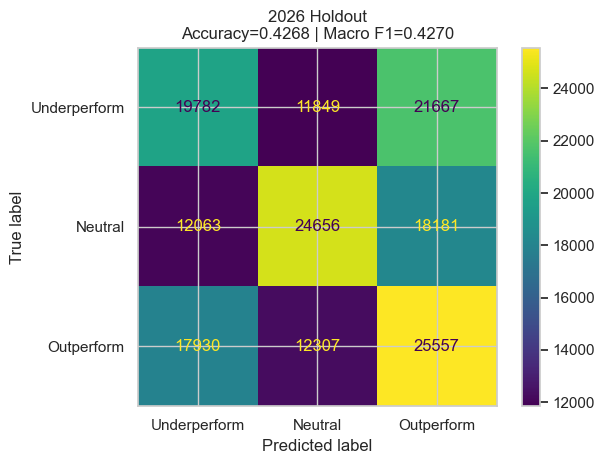

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
)

pred = model.predict(X_test).astype(int).ravel()

acc = accuracy_score(y_test, pred)
macro = f1_score(y_test, pred, average="macro")

print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {macro:.4f}\n")

print(classification_report(y_test, pred, digits=4))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Underperform", "Neutral", "Outperform"]
)
disp.plot(values_format="d")
plt.title(f"2026 Holdout\nAccuracy={acc:.4f} | Macro F1={macro:.4f}")
plt.tight_layout()
plt.show()

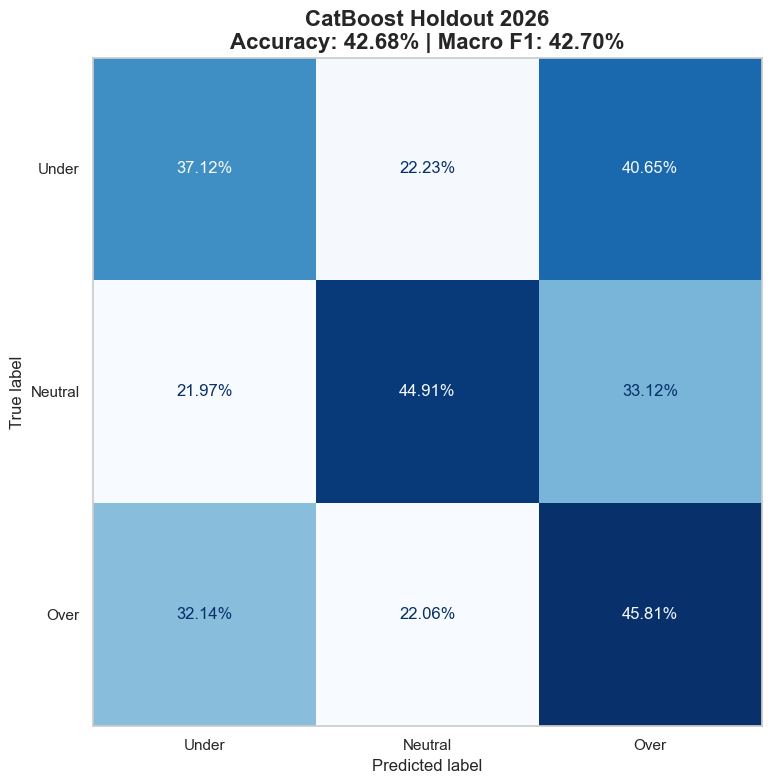

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score

pred = model.predict(X_test).astype(int).ravel()

acc = accuracy_score(y_test, pred)
macro = f1_score(y_test, pred, average="macro")

cm = confusion_matrix(y_test, pred, normalize="true")

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Under", "Neutral", "Over"]
)

disp.plot(
    cmap="Blues",
    values_format=".2%",
    colorbar=False,
    ax=ax
)

ax.set_title(
    f"CatBoost Holdout 2026\nAccuracy: {acc:.2%} | Macro F1: {macro:.2%}",
    fontsize=16,
    weight="bold"
)
ax.grid(False)
plt.tight_layout()
plt.savefig("holdout_2026_results.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
import pandas as pd

pd.Series(pred).value_counts(normalize=True).sort_index()

NameError: name 'pred' is not defined

In [21]:
y_test.value_counts(normalize=True).sort_index()

label
0    0.325004
1    0.334772
2    0.340224
Name: proportion, dtype: float64

In [46]:
HORIZON = 20
SKIP = 5
THRESHOLD = 0.005
MIN_GROUP = 3

cat = metadata["category"].reindex(prices.columns)

counts = cat.value_counts()

keep_cats = counts[
    (counts >= MIN_GROUP) &
    (counts.index != "Uncategorized")
].index

cols = cat[cat.isin(keep_cats)].index

px = prices[cols]
cat = cat[cols]

print(f'funds kept for labeling: {len(cols)} | categories: {cat.nunique()}')

# 20-day forward return skipping the next 5 days
fwd = px.shift(-(HORIZON + SKIP)) / px.shift(-SKIP) - 1.0

# category peer average excluding the fund itself
grp_sum = fwd.T.groupby(cat).transform('sum').T
grp_n = fwd.notna().T.groupby(cat).transform('sum').T

peer_mean = (
    (grp_sum - fwd.fillna(0)) /
    (grp_n - fwd.notna().astype(int)).replace(0, np.nan)
)

# relative performance vs peers
rel = fwd - peer_mean

# labels
label = pd.DataFrame(
    np.where(
        rel > THRESHOLD,
        'Outperform',
        np.where(rel < -THRESHOLD, 'Underperform', 'Neutral')
    ),
    index=rel.index,
    columns=rel.columns
).where(rel.notna())


def stack(df):
    s = df.stack(future_stack=True)
    s.index.names = ['date', 'fund_id']
    return s


labels_long = pd.concat(
    {
        'fwd_ret': stack(fwd),
        'rel': stack(rel),
        'label': stack(label)
    },
    axis=1
).dropna(subset=['label']).reset_index()

print('labels:', labels_long.shape)
print((labels_long['label'].value_counts(normalize=True) * 100).round(2))

funds kept for labeling: 1759 | categories: 36
labels: (3729760, 5)
label
Underperform    37.69
Outperform      37.14
Neutral         25.18
Name: proportion, dtype: float64


In [47]:
labels_long["label"].value_counts(normalize=True)
label_map = {
    "Underperform": 0,
    "Neutral": 1,
    "Outperform": 2
}

labels_long["target"] = labels_long["label"].map(label_map)

In [32]:
prices = pd.read_parquet(RAW / "prices.parquet")
metadata = pd.read_parquet(RAW / "metadata.parquet")

In [48]:
prices.columns

Index(['AAA', 'AAAU', 'AADR', 'AAXJ', 'ABCS', 'ABEQ', 'ACES', 'ACVF', 'ACWF',
       'ACWI',
       ...
       'YOLO', 'YXI', 'YYY', 'ZCAN', 'ZGBR', 'ZHOK', 'ZIG', 'ZJPN', 'ZROZ',
       'ZSL'],
      dtype='object', name='ticker', length=1975)

In [49]:
metadata.head()
metadata.index[:5]

Index(['AAA', 'AAAU', 'AADR', 'AAXJ', 'ABCS'], dtype='object', name='ticker')

# Figary labels

In [67]:
d.index.get_level_values('ticker').unique()


Index(['AADR', 'AAXJ', 'ACWF', 'ACWI', 'ACWX', 'ADRE', 'AEB', 'AFK', 'AFTY',
       'AGG',
       ...
       'SOXQ', 'CAPE', 'SCMB', 'FDIV', 'CVRT', 'JHMU', 'MJUS', 'BTC', 'JDIV',
       'XDIV'],
      dtype='object', name='ticker', length=1579)

In [84]:
print(d.shape)
print(figary_df.shape)

print(len(labels_long))
print(labels_long.index.equals(d.index))

print(labels_long.index.names)
print(d.index.names)
target = "label"

(3258519, 10)
(3226983, 12)
3729760
False
[None]
['date', 'ticker']


In [83]:
lbl = labels_long.set_index(["date", "fund_id"])
lbl.index.names = ["date", "ticker"]   # align names with d

figary_df = d.copy()
figary_df["target"] = lbl["target"]
figary_df["fwd_ret"] = lbl["fwd_ret"]   # attach it here too, replaces the later reindex cell

figary_df = figary_df.dropna(subset=["target"])
figary_df["target"] = figary_df["target"].astype(int)
target = "target"

print(figary_df.shape)   # should now be non-trivial, not (0, n)

(3226983, 12)


In [81]:
# rebuild target column safely
figary_df = d.copy()

target_series = labels_long["target"].reindex(figary_df.index)

figary_df["target"] = target_series

figary_df = figary_df.dropna(subset=["target"])
figary_df["target"] = figary_df["target"].astype(int)

# IMPORTANT
target = "target"

print(figary_df.shape)
print(target)
print(figary_df.columns)

(0, 11)
target
Index(['beta_60d', 'cat_n', 'peer_rank_20d', 'cs_rank_ret_5d', 'ret_20d_skip5',
       'vol_20d', 'rel_volume_20d', 'cs_rank_dollar_vol', 'vol_zscore',
       'label', 'target'],
      dtype='object')


In [60]:
figary_df = d.copy()
figary_df
target_series = labels_long["target"].reindex(figary_df.index)
figary_df["target"] = target_series

figary_df = figary_df.dropna(subset=["target"])
figary_df["target"] = figary_df["target"].astype(int)

# IMPORTANT
target = "target"

print(figary_df.shape)
print(target)
print(figary_df.columns)

(0, 11)
target
Index(['beta_60d', 'cat_n', 'peer_rank_20d', 'cs_rank_ret_5d', 'ret_20d_skip5',
       'vol_20d', 'rel_volume_20d', 'cs_rank_dollar_vol', 'vol_zscore',
       'label', 'target'],
      dtype='object')


In [51]:
figary_df = figary_df.dropna(subset=["target"])
figary_df["target"] = figary_df["target"].astype(int)

In [85]:
print(d.index.is_unique)
print(labels_long.index.is_unique)

print(d.shape)
print(labels_long.shape)

True
True
(3258519, 10)
(3729760, 6)


In [86]:
labels_long.index.duplicated().sum()

0

In [87]:
print(d.index.names)
print(labels_long.index.names)

print(d.index.dtype)
print(labels_long.index.dtype)

['date', 'ticker']
[None]
object
int64


In [88]:
common = d.index.intersection(labels_long.index)

print(len(common))
print(len(common) / len(d))

0
0.0


In [89]:
labels_long.head()

,date,fund_id,fwd_ret,rel,label,target
0,2016-07-11,AADR,0.011084,-0.033789,Underperform,0
1,2016-07-11,AAXJ,0.051138,0.006605,Outperform,2
2,2016-07-11,ACWF,0.023605,0.011984,Outperform,2
3,2016-07-11,ACWI,0.025566,0.014017,Outperform,2
4,2016-07-11,ACWX,0.036124,0.024966,Outperform,2


In [109]:
# train ONLY on 2025, test on 2026
train_start = pd.Timestamp("2025-01-01")
test_start  = pd.Timestamp("2026-01-01")
test_end    = pd.Timestamp("2026-12-31")

EMBARGO = HORIZON + SKIP   # 25 trading days

cut = test_start - pd.offsets.BDay(EMBARGO)   # ~late Nov 2025

date_index = figary_alive.index.get_level_values("date")

train_mask = (date_index >= train_start) & (date_index <= cut)
test_mask  = (date_index >= test_start) & (date_index <= test_end)

train  = figary_alive.loc[train_mask]
X_test = figary_alive.loc[test_mask, features]
y_test = figary_alive.loc[test_mask, target]

# val tail inside 2025 for early stopping
dates = np.sort(train.index.get_level_values("date").unique())
val_start = dates[int(len(dates) * 0.90)]      # last ~10% of 2025 dates
val_cut   = val_start - pd.offsets.BDay(EMBARGO)

train_dates = train.index.get_level_values("date")
fit_mask = train_dates <= val_cut
val_mask = train_dates >= val_start

X_fit, y_fit = train.loc[fit_mask, features], train.loc[fit_mask, target]
X_val, y_val = train.loc[val_mask, features], train.loc[val_mask, target]

print(f"fit={len(X_fit):,} val={len(X_val):,} test={len(X_test):,}")
print(f"fit : {train_dates[fit_mask].min().date()} → {train_dates[fit_mask].max().date()}")
print(f"val : {train_dates[val_mask].min().date()} → {train_dates[val_mask].max().date()}")

model.fit(X_fit, y_fit, eval_set=(X_val, y_val), verbose=100)

pred = model.predict(X_test).astype(int).ravel()
print(f"Macro F1 : {f1_score(y_test, pred, average='macro'):.4f}")
print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")

fit=237,348 val=28,704 test=137,592
fit : 2025-01-02 → 2025-09-22
val : 2025-10-27 → 2025-11-26
0:	learn: 0.4179177	test: 0.4123462	best: 0.4123462 (0)	total: 14.8ms	remaining: 1m 13s
100:	learn: 0.4504646	test: 0.4158101	best: 0.4164645 (99)	total: 1.27s	remaining: 1m 1s
200:	learn: 0.4651048	test: 0.4192599	best: 0.4192599 (200)	total: 2.5s	remaining: 59.8s
300:	learn: 0.4761278	test: 0.4206503	best: 0.4217027 (280)	total: 3.84s	remaining: 60s
400:	learn: 0.4850541	test: 0.4209947	best: 0.4218783 (350)	total: 5.21s	remaining: 59.8s
500:	learn: 0.4934023	test: 0.4214590	best: 0.4229740 (461)	total: 6.6s	remaining: 59.3s
600:	learn: 0.4994146	test: 0.4227550	best: 0.4235629 (565)	total: 7.98s	remaining: 58.4s
700:	learn: 0.5048681	test: 0.4233992	best: 0.4238338 (655)	total: 9.37s	remaining: 57.4s
800:	learn: 0.5094294	test: 0.4244582	best: 0.4246586 (799)	total: 10.8s	remaining: 56.5s
900:	learn: 0.5143200	test: 0.4252121	best: 0.4257246 (894)	total: 12.3s	remaining: 55.9s
1000:	learn

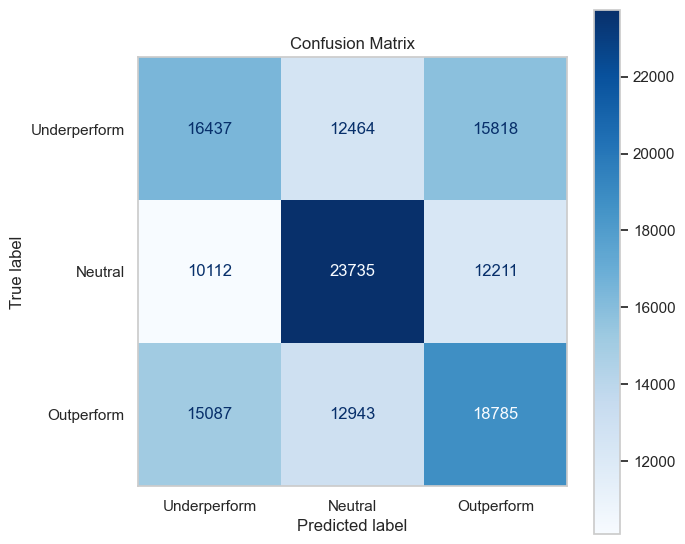

In [116]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Underperform", "Neutral", "Outperform"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)
ax.grid(False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [110]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[16437 12464 15818]
 [10112 23735 12211]
 [15087 12943 18785]]


In [111]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.39      0.37      0.38     44719
           1       0.48      0.52      0.50     46058
           2       0.40      0.40      0.40     46815

    accuracy                           0.43    137592
   macro avg       0.43      0.43      0.43    137592
weighted avg       0.43      0.43      0.43    137592



In [52]:
proba = model.predict_proba(X_test)
proba

array([[0.40600363, 0.23449005, 0.35950632],
       [0.48871163, 0.10192354, 0.40936483],
       [0.3231587 , 0.26825528, 0.40858602],
       ...,
       [0.37362345, 0.23632121, 0.39005534],
       [0.40284679, 0.17538525, 0.42176796],
       [0.42519871, 0.13181754, 0.44298375]])

In [53]:
proba = model.predict_proba(X_test)

score = proba[:,2] - proba[:,0]

tmp = pd.DataFrame({
    "score": score,
    "actual": y_test.values
})

tmp["decile"] = pd.qcut(tmp["score"], 10)

tmp.groupby("decile")["actual"].apply(
    lambda x: (x==2).mean()
)

C:\Windows\Temp\ipykernel_55916\2387141670.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("decile")["actual"].apply(


decile
(-0.392, -0.0657]      0.256708
(-0.0657, -0.0375]     0.388607
(-0.0375, -0.0189]     0.360919
(-0.0189, -0.00585]    0.305666
(-0.00585, 0.00516]    0.300960
(0.00516, 0.017]       0.342288
(0.017, 0.0291]        0.369232
(0.0291, 0.0431]       0.373724
(0.0431, 0.0653]       0.355327
(0.0653, 0.148]        0.372074
Name: actual, dtype: float64

In [54]:
score = proba[:,2]
tmp = pd.DataFrame({
    "score": score,
    "actual": y_test.values
})

tmp["decile"] = pd.qcut(tmp["score"], 10)

tmp.groupby("decile")["actual"].apply(
    lambda x: (x==2).mean()
)

C:\Windows\Temp\ipykernel_55916\572659835.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("decile")["actual"].apply(


decile
(0.0704, 0.246]    0.096449
(0.246, 0.345]     0.227610
(0.345, 0.382]     0.324143
(0.382, 0.394]     0.365503
(0.394, 0.403]     0.395269
(0.403, 0.411]     0.379787
(0.411, 0.419]     0.374549
(0.419, 0.429]     0.376016
(0.429, 0.444]     0.382495
(0.444, 0.497]     0.503698
Name: actual, dtype: float64

In [60]:
print("Universe mean:", tmp["fwd_ret"].mean())
print("Top decile:", tmp[tmp["decile"] == tmp["decile"].cat.categories[-1]]["fwd_ret"].mean())

Universe mean: 0.01421257792488479
Top decile: 0.03405575463620045


In [58]:
figary_df["fwd_ret"] = labels_long["fwd_ret"].reindex(figary_df.index)

# check
print(figary_df["fwd_ret"].describe())

count    3.226983e+06
mean     7.628016e-03
std      5.454218e-02
min     -7.888041e-01
25%     -1.405687e-02
50%      6.866349e-03
75%      3.217257e-02
max      1.195869e+00
Name: fwd_ret, dtype: float64


In [69]:
metadata= pd.read_csv(RAW / "metadata.csv")


In [74]:
metadata['category'].unique()

array(['Corporate Bonds', 'Uncategorized', 'Emerging Markets', 'Blend',
       'Energy', 'Value', 'Developed Markets', 'Frontier Markets',
       'Large Cap', 'Small Cap', 'Investment Grade Bonds', 'Trading',
       'Government Bonds', 'Factors', 'Technology', 'Industrials',
       'High Yield Bonds', 'Equities', 'Materials', 'Municipal Bonds',
       'Consumer Discretionary', 'Bonds', 'Health Care', 'Mid Cap',
       'Commodities Broad Basket', 'Financials', 'Growth',
       'Treasury Bonds', 'Money Market Instruments',
       'Commercial Real Estate', 'Derivatives', 'REITs', 'Micro Cap',
       'Cash', 'Communications', 'Consumer Staples', 'Utilities',
       'Currencies', 'Residential Real Estate',
       'Inflation-Protected Securities'], dtype=object)

In [76]:
metadata['category_group'].unique()

array(['Fixed Income', 'Commodities', 'Financials', 'Alternatives',
       'Energy', 'Equities', 'Health Care', 'Information Technology',
       'Industrials', 'Materials', 'Uncategorized', 'Utilities',
       'Real Estate', 'Derivatives', 'Consumer Discretionary',
       'Currencies', 'Communication Services', 'Consumer Staples'],
      dtype=object)

In [57]:
tmp = pd.DataFrame({
    "score": proba[:,2],
    "fwd_ret": figary_df.loc[X_test.index, "fwd_ret"]
})

tmp["decile"] = pd.qcut(tmp["score"], 10)

print(tmp.groupby("decile")["fwd_ret"].mean())

decile
(0.0704, 0.246]    0.004912
(0.246, 0.345]     0.006393
(0.345, 0.382]     0.010017
(0.382, 0.394]     0.012075
(0.394, 0.403]     0.013983
(0.403, 0.411]     0.014164
(0.411, 0.419]     0.015231
(0.419, 0.429]     0.015879
(0.429, 0.444]     0.015418
(0.444, 0.497]     0.034056
Name: fwd_ret, dtype: float64


C:\Windows\Temp\ipykernel_55916\3051306138.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tmp.groupby("decile")["fwd_ret"].mean())


In [57]:
figary_df


,,beta_60d,cat_n,peer_rank_20d,cs_rank_ret_5d,ret_20d_skip5,vol_20d,rel_volume_20d,cs_rank_dollar_vol,vol_zscore,label,target
date,ticker,,,,,,,,,,,


In [55]:
print(X_train.shape)
print(y_train.shape)

print(len(X_train))
print(len(y_train))

print(y_train.head())

(0, 8)
(0,)
0
0
Series([], Name: target, dtype: int32)


In [40]:
# train: before 2025
# validation: 2025
# test: 2026

date_index = figary_df.index.get_level_values("date")

train_mask = date_index < pd.Timestamp("2025-01-01")

val_mask = (
    (date_index >= pd.Timestamp("2025-01-01")) &
    (date_index <= pd.Timestamp("2025-12-31"))
)

test_mask = (
    (date_index >= pd.Timestamp("2026-01-01")) &
    (date_index <= pd.Timestamp("2026-12-31"))
)

X_train = figary_df.loc[train_mask, features]
y_train = figary_df.loc[train_mask, target]

X_val = figary_df.loc[val_mask, features]
y_val = figary_df.loc[val_mask, target]

X_test = figary_df.loc[test_mask, features]
y_test = figary_df.loc[test_mask, target]

model.fit(
    X_train,
    y_train)
pred_2026 = model.predict(X_test).astype(int).ravel()
proba_2026 = model.predict_proba(X_test)
print(pred_2026)
print(proba_2026)

CatBoostError: Labels variable is empty.

In [67]:
from sklearn.metrics import f1_score, classification_report

print("Macro F1:", f1_score(y_2026, pred_2026, average="macro"))
print(classification_report(y_2026, pred_2026))

Macro F1: 0.4807686693908007
              precision    recall  f1-score   support

           0       0.47      0.48      0.47     52572
           1       0.65      0.43      0.51     34324
           2       0.42      0.50      0.46     50696

    accuracy                           0.47    137592
   macro avg       0.51      0.47      0.48    137592
weighted avg       0.49      0.47      0.48    137592



In [68]:
tmp_2026 = pd.DataFrame({
    "score": proba_2026[:,2],
    "fwd_ret": figary_df.loc[X_2026.index, "fwd_ret"]
}).dropna()

tmp_2026["decile"] = pd.qcut(tmp_2026["score"], 10)

print(tmp_2026.groupby("decile", observed=False)["fwd_ret"].mean())

decile
(0.0506, 0.229]    0.001665
(0.229, 0.345]     0.002550
(0.345, 0.384]     0.008677
(0.384, 0.398]     0.008036
(0.398, 0.407]     0.008930
(0.407, 0.416]     0.009514
(0.416, 0.424]     0.014727
(0.424, 0.433]     0.016521
(0.433, 0.448]     0.017067
(0.448, 0.507]     0.029052
Name: fwd_ret, dtype: float64


In [78]:
print(d.shape)
print(train_mask.sum())
print(test_mask.sum())

(3258519, 10)
0
0


In [69]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

ValueError: Found input variables with inconsistent numbers of samples: [137592, 327219]

In [70]:
top = tmp_2026.nlargest(len(tmp_2026)//10, "score")

print(top["fwd_ret"].mean())
print(top["fwd_ret"].std())

0.029047849404511498
0.08656945499409543


In [112]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2026, pred_2026)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Underperform", "Neutral", "Outperform"]
)
ax.grid(False)

disp.plot()
plt.show()

NameError: name 'y_2026' is not defined

In [72]:
# bottom decile return
bottom = tmp_2026.nsmallest(len(tmp_2026)//10, "score")["fwd_ret"].mean()

print("Bottom:", bottom)
print("Top:", tmp_2026.nlargest(len(tmp_2026)//10, "score")["fwd_ret"].mean())
print("Spread:", tmp_2026.nlargest(len(tmp_2026)//10, "score")["fwd_ret"].mean() - bottom)

Bottom: 0.001664653638909521
Top: 0.029047849404511498
Spread: 0.027383195765601977


In [73]:
top = tmp_2026.nlargest(len(tmp_2026)//10, "score")["fwd_ret"].mean()
bottom = tmp_2026.nsmallest(len(tmp_2026)//10, "score")["fwd_ret"].mean()
universe = tmp_2026["fwd_ret"].mean()

print("Universe mean:", universe)
print("Top decile:", top)
print("Bottom decile:", bottom)
print("Spread:", top - bottom)
print("Top/Bottom ratio:", top / bottom)

Universe mean: 0.011674123605599628
Top decile: 0.029047849404511498
Bottom decile: 0.001664653638909521
Spread: 0.027383195765601977
Top/Bottom ratio: 17.449785784591274


In [75]:
print("Spearman correlation:",
      tmp_2026["score"].corr(tmp_2026["fwd_ret"], method="spearman"))

Spearman correlation: 0.12269735026002229


In [78]:
tmp_2026 = tmp_2026.copy()

tmp_2026["date"] = tmp_2026.index.get_level_values("date")

top50 = (
    tmp_2026
    .sort_values(["date", "score"], ascending=[True, False])
    .groupby("date")
    .head(50)
)

print("Top 50 average 20d return:")
print(top50["fwd_ret"].mean())

print("Number of picks:")
print(len(top50))

ValueError: 'date' is both an index level and a column label, which is ambiguous.

In [79]:
tmp_2026 = tmp_2026.reset_index()

top50 = (
    tmp_2026
    .sort_values(["date", "score"], ascending=[True, False])
    .groupby("date")
    .head(50)
)

print("Top 50 average 20d return:")
print(top50["fwd_ret"].mean())

print("Number of picks:")
print(len(top50))

ValueError: cannot insert date, already exists

In [80]:
tmp_2026 = tmp_2026.drop(columns=["date"], errors="ignore")
tmp_2026 = tmp_2026.reset_index()

top50 = (
    tmp_2026
    .sort_values(["date", "score"], ascending=[True, False])
    .groupby("date")
    .head(50)
)

print("Top 50 average 20d return:")
print(top50["fwd_ret"].mean())

print("Number of picks:")
print(len(top50))

Top 50 average 20d return:
0.01881682772202463
Number of picks:
5250


In [81]:
# daily portfolio returns
daily_returns = top50.groupby("date")["fwd_ret"].mean()

print(daily_returns.mean())
print(daily_returns.std())
print(daily_returns.mean() / daily_returns.std())  # rough Sharpe-like metric

0.018816827722024625
0.052243970458576
0.36017223723346986


In [ ]:
import shap

# Use your 2026 test sample (or a smaller sample)
X_shap = X_2026.sample(5000, random_state=42)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=features
)

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
pip install shap

In [118]:
YUHH= pd.read_csv(RAW / "market_data.csv")

C:\Windows\Temp\ipykernel_31196\1014644667.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,

In [119]:
YUHH

,Price,Close,Close.1,Close.2,Close.3,Close.4,Close.5,Close.6,Close.7,Close.8,...,Volume.1965,Volume.1966,Volume.1967,Volume.1968,Volume.1969,Volume.1970,Volume.1971,Volume.1972,Volume.1973,Volume.1974
0,Ticker,AAA,AAAU,AADR,AAXJ,ABCS,ABEQ,ACES,ACVF,ACWF,...,YOLO,YXI,YYY,ZCAN,ZGBR,ZHOK,ZIG,ZJPN,ZROZ,ZSL
1,date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-07-11,NaN,NaN,35.378570556640625,46.13690948486328,NaN,NaN,NaN,NaN,18.173181533813477,...,NaN,4200,43100,201.0,624.0,NaN,NaN,0.0,24600,787
3,2016-07-12,NaN,NaN,36.02705764770508,46.7688102722168,NaN,NaN,NaN,NaN,18.173181533813477,...,NaN,2050,60500,315.0,285.0,NaN,NaN,117.0,103300,878
4,2016-07-13,NaN,NaN,35.828914642333984,46.718910217285156,NaN,NaN,NaN,NaN,18.746137619018555,...,NaN,2150,23800,0.0,3846.0,NaN,NaN,503.0,17700,761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511,2026-07-06,25.037001,41.040001,84.169998,117.57,34.098,37.664001,34.959999,54.122002,59.304199,...,89300.0,800,231400,NaN,NaN,NaN,500.0,NaN,807100,1816800
2512,2026-07-07,25.031,40.57,83.0,114.25,34.187,37.768002,33.279999,53.779999,58.830002,...,15100.0,1600,178300,NaN,NaN,NaN,1600.0,NaN,958100,2448700
2513,2026-07-08,25.01,40.240002,83.089996,115.209999,33.716,37.273998,33.259998,53.673,58.703098,...,33700.0,3400,242400,NaN,NaN,NaN,500.0,NaN,548100,2840900
2514,2026-07-09,25.0,40.639999,84.150002,116.290001,34.039001,37.27,33.700001,54.132,59.153999,...,8900.0,1800,167700,NaN,NaN,NaN,1400.0,NaN,1174800,1946900
